In [1]:
import pandas as pd
import numpy as np
import json
import math
import os

def get_permutation_index(permutation):
    
    # Check it is a valid permutation
    assert np.min(permutation) == 0
    assert np.max(permutation) == len(permutation)-1
    assert len(set(permutation)) == len(permutation)

    permutation = np.array(permutation)
    index = 0
    n_choices = math.factorial(len(permutation))
    for _ in range(len(permutation)):
        value = permutation[0]
        n_choices //= len(permutation)
        index += n_choices * value
        permutation = permutation[1:]
        permutation = np.where(permutation > value, permutation-1, permutation)

    return index

def load_contingency_matrix(results_dir, return_all_samples=False):

    with open(results_dir, 'r') as f:
        data = json.load(f)
    
    input_dataset_path = data['input_dataset']
    results = data['results']
    
    with open(input_dataset_path, 'r') as f:
        input_dataset = json.load(f)
    
    top_k = input_dataset['top_k']
    samples_per_query = input_dataset['samples_per_query']
    if samples_per_query == 0:
        samples_per_query = math.factorial(top_k)
    
    # This is required by the statistical test
    assert input_dataset['share_permutations']
    
    skipped_samples = list()
    skipped_queries = set()
    for i,result_sample in enumerate(results):
        pred_pos = result_sample['predicted_pos']
        if pred_pos is None or not isinstance(pred_pos, int) or pred_pos < 1 or pred_pos > top_k:
            skipped_queries.add(i // samples_per_query)
            skipped_samples.append(i)
    
    
    skip_samples = True
    skip_queries = False
    cm = np.zeros((top_k, samples_per_query))
    unshuffled_cm = np.zeros((top_k, samples_per_query))

    all_samples = {'query': [], 'permutation': [], 'true_pred_pos': [], 'raw_pred_pos': []}

    for i,(result_sample,query_info) in enumerate(zip(results, input_dataset['queries'])):
        query_id = i//samples_per_query
        permutation_id = i%samples_per_query
    
        if skip_samples and i in skipped_samples:
            continue
        if skip_queries and query_id in skipped_queries:
            continue
    
        pred_pos = result_sample['predicted_pos'] - 1
        true_pred_pos = query_info['permutation'][pred_pos]
        unshuffled_cm[true_pred_pos,permutation_id] += 1
        cm[pred_pos,permutation_id] += 1

        if return_all_samples:
            all_samples['query'].append(query_info['query'])
            all_samples['permutation'].append(get_permutation_index(query_info['permutation']))
            all_samples['true_pred_pos'].append(true_pred_pos)
            all_samples['raw_pred_pos'].append(pred_pos)


    if return_all_samples:
        all_samples = pd.DataFrame(all_samples)
        return cm, unshuffled_cm, input_dataset, samples_per_query, top_k, all_samples
    return cm, unshuffled_cm, input_dataset, samples_per_query, top_k

In [2]:
contingency_values_as_true_positions = False

dataset_name = 'shuffled_products'
experiment_name = 'position_bias__share'
filename = 'evaluation_llama3.1:8b-instruct-fp16.json'
results_dir = os.path.join('results', dataset_name, experiment_name, filename)

cm, unshuffled_cm, input_dataset, samples_per_query, top_k = load_contingency_matrix(results_dir)

In [3]:
from scipy.stats import chi2_contingency

shuffles_subsample_size = 120
num_queries = len(input_dataset['queries']) // samples_per_query

# Generate a subsample
shuffles_subsample_indices = np.arange(samples_per_query)
np.random.shuffle(shuffles_subsample_indices)
shuffles_subsample_indices = shuffles_subsample_indices[:shuffles_subsample_size]

contingency_matrix_test = cm.copy()
contingency_matrix_test = contingency_matrix_test[:,shuffles_subsample_indices]

# Run chi-squared test for independence
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_matrix_test, correction=False)

# Output results
print(f"Chi-squared statistic: {chi2_stat:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("Reject the null hypothesis: distributions differ across permutations.")
else:
    print("Fail to reject the null hypothesis: no evidence that y affects the distribution.")

cramers_v = np.sqrt(chi2_stat / (np.sum(contingency_matrix_test) * (min(contingency_matrix_test.shape) - 1)))
print("Cramér’s V:", cramers_v)

np.sum(cm)

Chi-squared statistic: 2903.9542
Degrees of freedom: 476
P-value: 0.0000e+00
Reject the null hypothesis: distributions differ across permutations.
Cramér’s V: 0.07796032204054451


119449.0

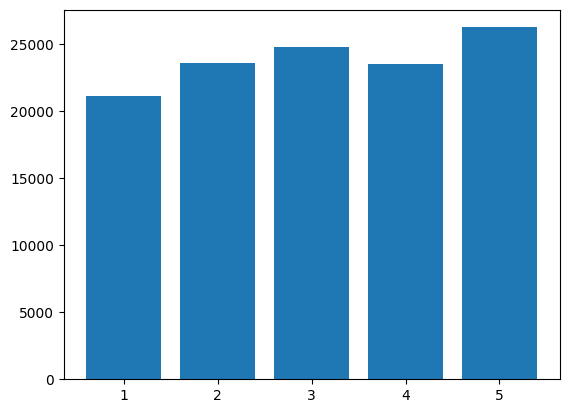

array([21164., 23639., 24840., 23526., 26280.])

In [4]:
import matplotlib.pyplot as plt

plt.bar(range(1, top_k+1), np.sum(cm, axis=1))
plt.savefig(f"figures/raw_probability_distribution.pdf", format="pdf", bbox_inches="tight")
plt.show()

np.sum(cm, axis=1)

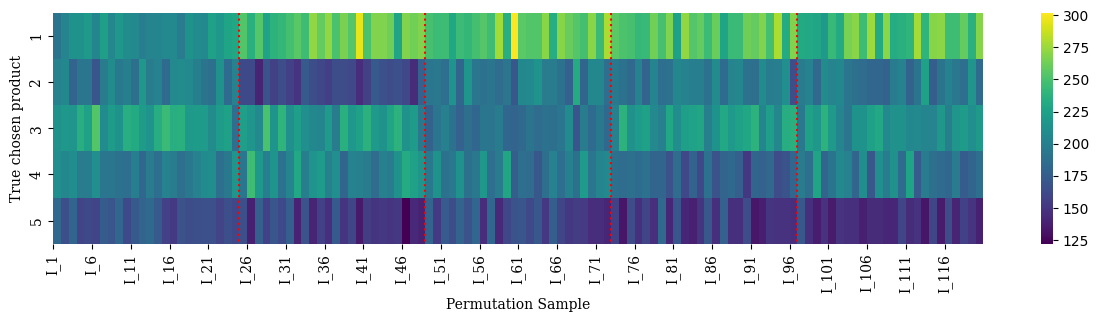

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

swap_axes = False

fig, ax = plt.subplots(figsize=(8, 10) if swap_axes else (15, 3))
sns.heatmap(unshuffled_cm.T if swap_axes else unshuffled_cm, cmap="viridis", ax=ax)

for i in range(1, top_k):
    ax.plot([0, top_k] if swap_axes else [24*i, 24*i], [24*i, 24*i] if swap_axes else [0, top_k], linestyle = 'dotted', color='red')

step = 5
tick_locs = list(range(0, samples_per_query, step))
tick_labels = [f"I_{s+1}" for s in tick_locs]

set_xticklabels = ax.set_yticklabels if swap_axes else ax.set_xticklabels
set_xticks = ax.set_yticks if swap_axes else ax.set_xticks
set_yticklabels = ax.set_xticklabels if swap_axes else ax.set_yticklabels
set_yticks = ax.set_xticks if swap_axes else ax.set_yticks
set_xlabel = ax.set_ylabel if swap_axes else ax.set_xlabel
set_ylabel = ax.set_xlabel if swap_axes else ax.set_ylabel

font_config = {'fontname':'Serif'}

set_yticklabels(range(1, top_k+1), **font_config)
set_xticks(tick_locs)
set_xticklabels(tick_labels, **font_config)

set_ylabel("True chosen product", **font_config)
set_xlabel("Permutation Sample", **font_config)
# ax.set_title("True chosen product Distribution per Permutation", **font_config)

plt.savefig(f"figures/all_distribution_probabilities__{'vertical' if swap_axes else 'horizontal'}.pdf", format="pdf", bbox_inches="tight")

plt.show()

In [6]:
def compute_blocks(product_pos, top_k, samples_per_query, input_dataset):
    blocks = []
    for block_pos in range(top_k):
        blocks.append([])
        for i in range(samples_per_query):
            permutation = input_dataset['queries'][i]['permutation']
            if permutation[product_pos] == block_pos:
                blocks[-1].append(i)
    return blocks

[]

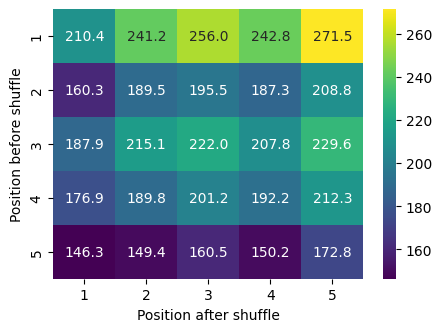

In [7]:
import seaborn as sns

def plot_bias_interpretability(unshuffled_cm, input_dataset, top_k, ax, plot_nums, show_x_axis=True, show_y_axis=True, ranges=None, show_colorbar=True):

    # Input: array of shape (top_k, samples_per_query)
    #  - Each column represents the probability distribution (non-normalized) of selecting 
    #    the ith-product (i is the row)
    # contingency_matrix
    
    # Output: array of shape (top_k, top_k)
    #  - Each row represents the means of counts of selected products that were on position i (row) and
    #    was moved to position j (column)
    matrix_counts = np.zeros((top_k, top_k))
    
    
    for orig_pos in range(top_k):
    
        test_set = set()
    
        for target_pos in range(top_k):
    
            # Array of shape (top_k, samples_per_query//top_k)
            #  - Each ith-row (block) represents a set of indices of shuffles, 
            #    where these shuffles moves products from position i to target_pos
            blocks = np.array(compute_blocks(target_pos, top_k, samples_per_query, input_dataset))
    
            # List of counts (each one is like a sample), where the selected product was at orig_pos, 
            # was moved to the target_pos and it was selected by the model
            counts = unshuffled_cm[orig_pos, blocks[orig_pos]]
            test_set.update(blocks[orig_pos])
            
            # Compute the mean for a robust representation
            mean = np.mean(counts)
    
            matrix_counts[orig_pos, target_pos] = mean
    
        assert len(test_set) == samples_per_query

    vmin = ranges[0] if ranges is not None else None
    vmax = ranges[1] if ranges is not None else None
    sns.heatmap(matrix_counts, vmin=vmin, vmax=vmax, cmap="viridis", ax=ax, annot=plot_nums, fmt='.1f', cbar=show_colorbar)

    if show_x_axis:
        ax.set_xticklabels(range(1, top_k+1))
        ax.set_xlabel('Position after shuffle')
    else:
        ax.set_xticklabels([])

    if show_y_axis:
        ax.set_ylabel('Position before shuffle')
        ax.set_yticklabels(range(1, top_k+1))
    else:
        ax.set_yticklabels([])

    ax.tick_params(left=show_y_axis, bottom=show_x_axis)

    return matrix_counts


fig, ax = plt.subplots(figsize=(5, 3.5))
plot_bias_interpretability(unshuffled_cm, input_dataset, top_k, ax, plot_nums=True)

plt.savefig(f"figures/bias_analysis.pdf", format="pdf", bbox_inches="tight")

plt.plot()

In [8]:
from tqdm.auto import tqdm

models = [
    'DeepSeek R1 32B (Qwen)',
    'DeepSeek R1 7B (Qwen)',
    'DeepSeek R1 8B (LLaMA)',
    'LLaMA 3.1 8B',
    'LLaMA 4 Scout',
    'GPT OSS 120B',
    'GPT-OSS 20B',
    'LLaMA 3.1 70B',
]

filenames = {
    'DeepSeek R1 32B (Qwen)': 'evaluation_deepseek-r1_32b-qwen-distill-fp16.json',
    'DeepSeek R1 7B (Qwen)': 'evaluation_deepseek-r1_7b-qwen-distill-fp16.json',
    'DeepSeek R1 8B (LLaMA)': 'evaluation_deepseek-r1_8b-llama-distill-fp16.json',
    'GPT OSS 120B': 'evaluation_gpt-oss:120b.json',
    'GPT-OSS 20B': 'evaluation_gpt-oss:20b.json',
    'LLaMA 3.1 70B': 'evaluation_llama3.1_70b-instruct-fp16.json',
    'LLaMA 3.1 8B': 'evaluation_llama3.1:8b-instruct-fp16.json',
    'LLaMA 4 Scout': 'evaluation_llama4:scout.json'
}

# We use llama3.1 70 fp16 only on the 730 queries dataset
if dataset_name != 'shuffled_products':
    filenames['LLaMA 3.1 70B'] = 'evaluation_llama3.1_70b-instruct-q8_0.json'

cm_set = dict()

for model_name in tqdm(models):

    results_dir = os.path.join('results', dataset_name, experiment_name, filenames[model_name])
    cm, unshuffled_cm, input_dataset, samples_per_query, top_k, all_samples = load_contingency_matrix(results_dir, return_all_samples=True)

    cm_set[model_name] = {
        'cm': cm,
        'unshuffled_cm': unshuffled_cm,
        'input_dataset': input_dataset,
        'samples_per_query': samples_per_query,
        'top_k': top_k,
        'all_samples': all_samples
    }

  0%|          | 0/8 [00:00<?, ?it/s]

23.283662440591577

DeepSeek R1 32B (Qwen) & 0.0000e+00 & 0.0784 \\
DeepSeek R1 7B (Qwen) & 2.1390e-272 & 0.0749 \\
DeepSeek R1 8B (LLaMA) & 0.0000e+00 & 0.0769 \\
LLaMA 3.1 8B & 0.0000e+00 & 0.0780 \\
LLaMA 4 Scout & 3.3634e-184 & 0.0660 \\
GPT OSS 120B & 1.0722e-251 & 0.0706 \\
GPT-OSS 20B & 2.4272e-116 & 0.0574 \\
LLaMA 3.1 70B & 2.0281e-285 & 0.0734 \\


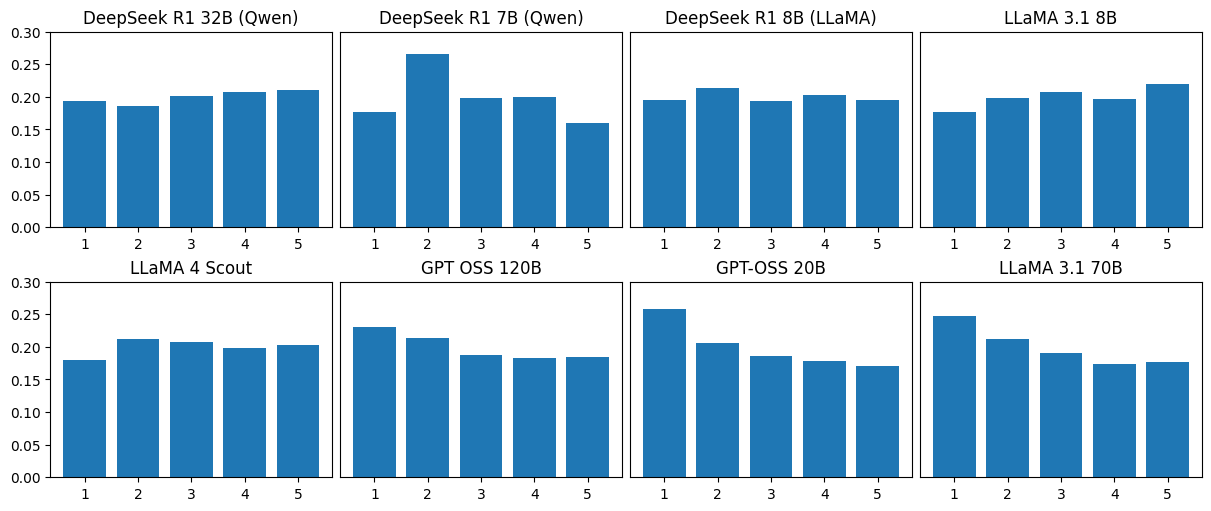

        Model name & TV & Sensitivity \\
        \midrule
        DeepSeek R1 32B (Qwen) & $1.985$ & $23.284$ \\
        DeepSeek R1 7B (Qwen) & $6.530$ & $38.060$ \\
        DeepSeek R1 8B (LLaMA) & $1.650$ & $30.280$ \\
        LLaMA 3.1 8B & $2.797$ & $32.155$ \\
        LLaMA 4 Scout & $2.172$ & $23.234$ \\
        GPT OSS 120B & $4.417$ & $16.554$ \\
        GPT-OSS 20B & $6.357$ & $17.996$ \\
        LLaMA 3.1 70B & $5.925$ & $24.252$ \\


In [25]:
from scipy.stats import chisquare
import random

ncols = 4
normalize_plot = True
nrows = len(models) // ncols
if len(models)%ncols != 0:
    nrows += 1

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 5), constrained_layout = True)

# https://datascience.stackexchange.com/questions/9262/calculating-kl-divergence-in-python
def KL(P,Q):
    """ Epsilon is used here to avoid conditional code for
    checking that neither P nor Q is equal to 0. """
    epsilon = 0.00001
    # You may want to instead make copies to avoid changing the np arrays.
    P = np.array(P)+epsilon
    Q = np.array(Q)+epsilon
    divergence = np.sum(P*np.log(P/Q))
    return divergence

def entropy(counts):

    p = counts / counts.sum()
    log_p = np.log(p) # base e
    entropy = -np.sum(p * log_p)

    return entropy

def total_variation_distance(p):
    p = np.asarray(p, dtype=float)
    
    # Validate
    assert np.isclose(p.sum(), 1.0), "Probabilities must sum to 1"
    assert np.all(p >= 0), "Probabilities must be non-negative"
    
    k = len(p)
    uniform = np.ones(k) / k
    
    return 0.5 * np.sum(np.abs(p - uniform))

def exp_notation_latex(number, n_significant):
    str_format = f'{{:.{n_significant}e}}'
    str_format = str_format.format(number)
    pos = str_format.find('e')
    significant = str_format[:pos]
    exp = int(str_format[pos+1:])
    return f'{significant} \cdot 10^{{{exp}}}'

def compute_sensitivity(data):

    sensitivity_mean = 0
    query_groups = data.groupby('query')
    for query, query_data in query_groups:
        majority_product = query_data['true_pred_pos'].mode().tolist()[0]
        chosen_product_count = sum(query_data['true_pred_pos'] == majority_product)
        query_sensitivity = 1 - chosen_product_count / len(query_data)
        sensitivity_mean += query_sensitivity
    sensitivity_mean /= len(query_groups)

    return sensitivity_mean

contingency_results = dict()
uniformity_results = dict()
stats = dict()

for i,model_name in enumerate(models):
    x_ticks = range(1, cm_set[model_name]['top_k']+1)
    counts = np.sum(cm_set[model_name]['cm'], axis=1)
    axs[i//ncols][i%ncols].bar(x_ticks, counts/np.sum(counts) if normalize_plot else counts)
    axs[i//ncols][i%ncols].set_ylim(0, 0.3 if normalize_plot else 33000)
    axs[i//ncols][i%ncols].set_xticks(range(1, cm_set[model_name]['top_k']+1))
    if i%ncols != 0:
        axs[i//ncols][i%ncols].get_yaxis().set_visible(False)
    axs[i//ncols][i%ncols].title.set_text(model_name)

    uniform_distribution = np.array([1/cm_set[model_name]['top_k'] for _ in range(cm_set[model_name]['top_k'])])
    stats[model_name] = {
        'kl_divergence': KL(counts/counts.sum(), uniform_distribution),
        'entropy': entropy(counts),
        'total_variance': total_variation_distance(counts/counts.sum()),
        'permutation_sensitivity': compute_sensitivity(cm_set[model_name]['all_samples'])
    }

    # Run chi-squared test for independence
    contingency_matrix_test = cm_set[model_name]['cm']
    chi2_stat, p_value, dof, expected = chi2_contingency(contingency_matrix_test, correction=False)
    cramers_v = np.sqrt(chi2_stat / (np.sum(contingency_matrix_test) * (min(contingency_matrix_test.shape) - 1)))

    contingency_results[model_name] = {
        'p_value': p_value,
        'cramers_v': cramers_v
    }


for model_name, model_results in contingency_results.items():
    print(f'{model_name} & {model_results["p_value"]:.4e} & {model_results["cramers_v"]:.4f} \\\\')



if len(models)%ncols != 0:
    fig.delaxes(axs[nrows-1][len(models)%ncols])
plt.savefig(f"figures/all_raw_probability_distributions.pdf", format="pdf", bbox_inches="tight")
plt.show()

print('        Model name & TV & Sensitivity \\\\')
print('        \midrule')
for model_name, model_stats in stats.items():
    # print(f'{model_name} & ${exp_notation_latex(model_stats["kl_divergence"], 3)}$ & ${model_stats["entropy"]:.3f}$ & ${100*model_stats["total_variance"]:.3f}$ \\\\')
    print(f'        {model_name} & ${100*model_stats["total_variance"]:.3f}$ & ${100*model_stats["permutation_sensitivity"]:.3f}$ \\\\')

0.3417361006848012 0.2870158270352875
9.916839449004151e-05 0.03482009017825132
0.35741828953578636 0.28801863437604064
0.24397615786953594 0.2789980757552586
0.25266501499703403 0.2787156321916418
0.030783566768643578 0.17989114941070172
0.0001548919058546746 0.044564545478092875
0.0030192187328676027 0.0881076377247615


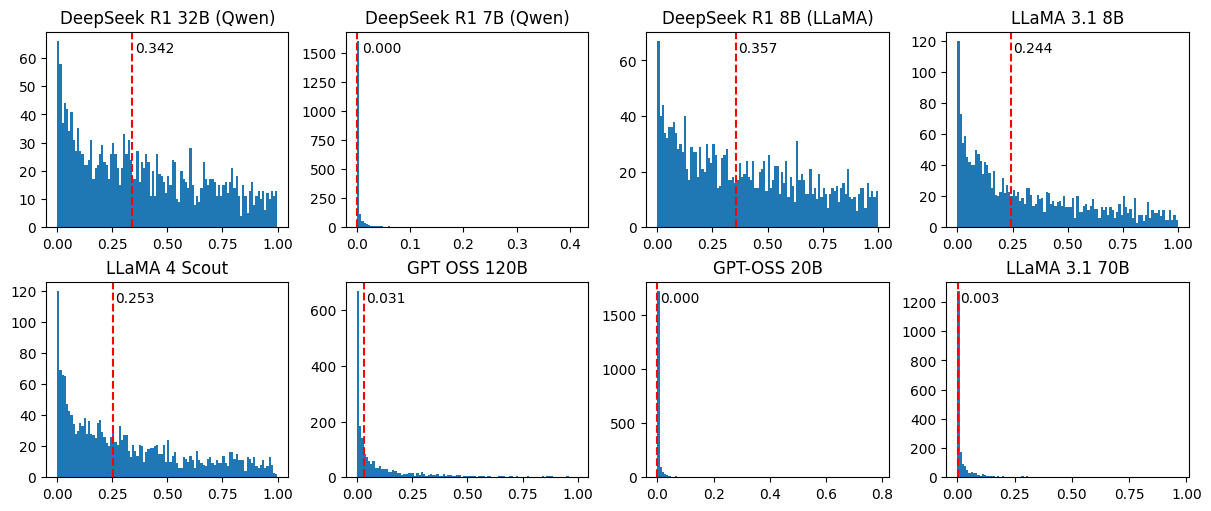

In [12]:
ncols = 4
nrows = len(models) // ncols
if len(models)%ncols != 0:
    nrows += 1

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 5), constrained_layout = True)

for i,model_name in enumerate(models):

    p_values = []

    grouped_queries = dict()
    for query, group in cm_set[model_name]['all_samples'].groupby('query'):
        grouped_queries[query] = group['raw_pred_pos'].tolist()
    for _ in range(2000):
        # Run subsampled test of uniformity
        subsampled_results = []
        for query, pred_positions in grouped_queries.items():
            subsampled_results.append(random.choice(pred_positions))
        _, subsampled_results_counts = np.unique(subsampled_results, return_counts=True)
        stat, p_value = chisquare(
            subsampled_results_counts, 
            uniform_distribution * len(subsampled_results))
        
        p_values.append(p_value)

    mean = np.mean(p_values)
    median = np.median(p_values)
    std = np.std(p_values)

    axs[i//ncols][i%ncols].hist(p_values, bins=100)
    axs[i//ncols][i%ncols].axvline(median, color='r', linestyle='--')
    axs[i//ncols][i%ncols].text(median+0.01, axs[i//ncols][i%ncols].get_ylim()[1]*0.95, f'{median:.3f}', va='top')
    axs[i//ncols][i%ncols].set_title(model_name)
    print(median, std)

plt.show()

0.014195235636309747 0.051260053892537724
0.020684421676742115 0.1024504715205632
0.012307995394266295 0.04376347021423749
0.021003320746336485 0.07834618418257927
0.02141943860915692 0.06159801906412372
0.03263675058565222 0.09964978679967011
0.010895168410512104 0.04487684241051317
0.02436632271343882 0.1154244411357564


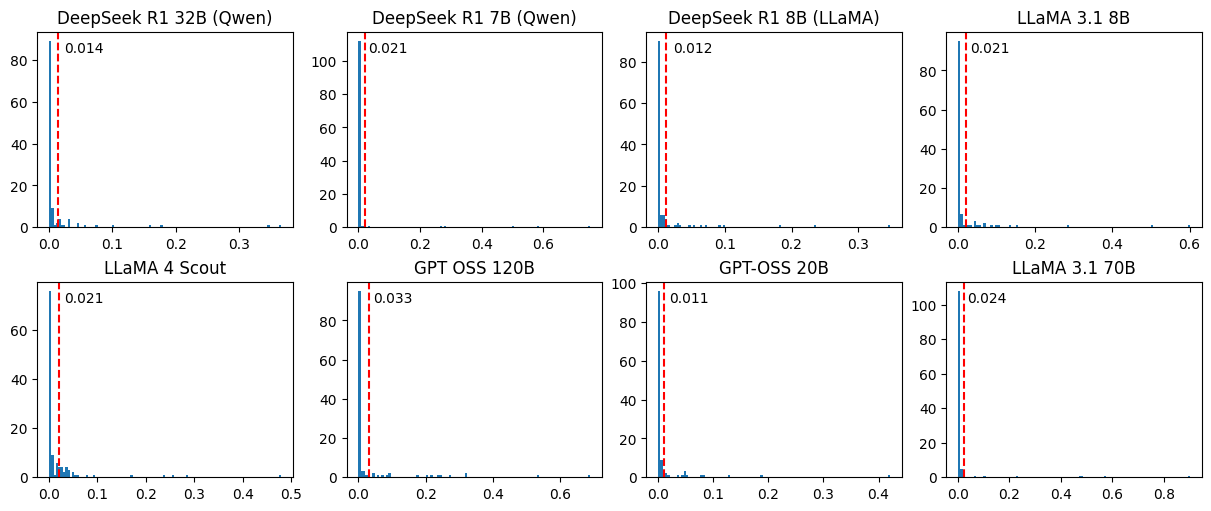

In [13]:
ncols = 4
nrows = len(models) // ncols
if len(models)%ncols != 0:
    nrows += 1

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 5), constrained_layout = True)

for i,model_name in enumerate(models):

    p_values = []

    grouped_queries = dict()
    for permutation_id, group in cm_set[model_name]['all_samples'].groupby('permutation'):

        _, distribution_x_cond_permutation = np.unique(group['raw_pred_pos'], return_counts=True)
        uniform_distribution = np.array([1/cm_set[model_name]['top_k'] for _ in range(cm_set[model_name]['top_k'])])

        stat, p_value = chisquare(
            distribution_x_cond_permutation, 
            uniform_distribution * len(group['raw_pred_pos']))
        
        p_values.append(p_value)

    mean = np.mean(p_values)
    std = np.std(p_values)

    axs[i//ncols][i%ncols].hist(p_values, bins=100)
    axs[i//ncols][i%ncols].axvline(mean, color='r', linestyle='--')
    axs[i//ncols][i%ncols].text(mean+0.01, axs[i//ncols][i%ncols].get_ylim()[1]*0.95, f'{mean:.3f}', va='top')
    axs[i//ncols][i%ncols].set_title(model_name)
    print(mean, std)

plt.show()

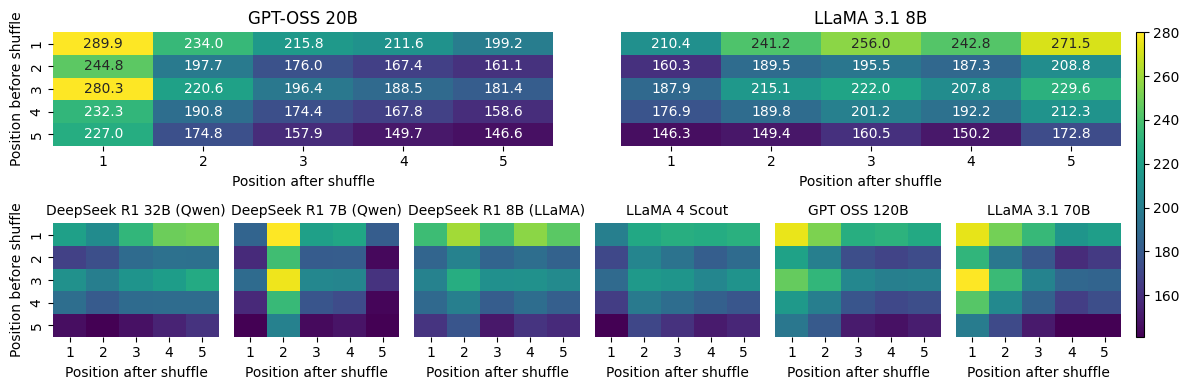

In [14]:
import matplotlib.gridspec as gridspec

highlighted_models = ['GPT-OSS 20B', 'LLaMA 3.1 8B']
other_models = [model for model in models if model not in highlighted_models]

fig = plt.figure(figsize=(12, 4))
gs = gridspec.GridSpec(2, len(highlighted_models)*len(other_models)+1, 
                       figure=fig, width_ratios=[1]*(len(highlighted_models)*len(other_models)) + [0.1])

# Compute ranges (add an offset to highlight less biased models)
vmin = min([np.min(data['unshuffled_cm']) for data in cm_set.values()])+40
vmax = max([np.max(data['unshuffled_cm']) for data in cm_set.values()])-40

# Row 1 (highlighted models)
highlighted_axs = []
for i,model in enumerate(highlighted_models):
    grid_min = i*len(other_models)
    grid_max = (i+1)*len(other_models)
    ax = fig.add_subplot(gs[0, grid_min:grid_max])
    plot_bias_interpretability(
        cm_set[model]['unshuffled_cm'], 
        cm_set[model]['input_dataset'], 
        cm_set[model]['top_k'], 
        ax, 
        plot_nums=True,
        ranges=(vmin,vmax),
        show_y_axis=(i==0),
        show_colorbar=False
    )
    ax.title.set_text(model)
    highlighted_axs.append(ax)

# Row 2 (rest of models)
for i,model in enumerate(other_models):
    # plot_bias_interpretability(plot_nums, show_x_axis=True, show_y_axis=True, ranges=None, show_colorbar=True)
    ax = fig.add_subplot(gs[1, (i*len(highlighted_models)):((i+1)*len(highlighted_models))])
    plot_bias_interpretability(
        cm_set[model]['unshuffled_cm'], 
        cm_set[model]['input_dataset'], 
        cm_set[model]['top_k'], 
        ax, 
        plot_nums=False,
        ranges=(vmin,vmax),
        show_y_axis=(i==0),
        show_colorbar=False
    )
    ax.title.set_text(model)
    ax.title.set_fontsize(10)

# Colorbar
cax = fig.add_subplot(gs[0:2, -1])
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])  # dummy mappable
fig.colorbar(sm, cax=cax)

plt.tight_layout()

# Add margin to first row
margin = 0.05
for i,ax in enumerate(highlighted_axs):
    pos = ax.get_position()
    if i == 0:
        x_offset = 0
    elif i == len(highlighted_axs)-1:
        x_offset = margin/2.3
    else:
        x_offset = margin/2.3
    ax.set_position([pos.x0+x_offset, pos.y0, pos.width*(1-margin), pos.height])

plt.savefig(f"figures/all_bias_analysis.pdf", format="pdf", bbox_inches="tight")
plt.show()